In [ ]:
import numpy as np
from astropy import units as u
from astropy.table import Table
from astropy.time import Time
from WDBinary import WDBinary
from SLBlensing import SLBlensing

from scipy import integrate
from astropy.constants import G, c, M_sun

import matplotlib.pyplot as plt
from matplotlib import gridspec

In [2]:
# base params
mass_wd  = 0.634
r_wd = 0.01166 * u.Rsun
l_wd = 0.00120
mass_star = 1.042
r_star = 0.964 * u.Rsun
l_star = 1.0
ecc = 0.0147        # from e cos ω ≈ 0.014713, e sin ω ≈ 0
a  = 0.4605 * u.au
d = 808.0 * u.pc
inc_deg  = 89.607 * u.deg
omega_deg = 0.0 * u.deg   # e sin ω ≈ 0 means ω ≈ 0 or 180
cycle=1
N = 200000

# varying inclination

In [ ]:
binaries_inc = []
inclinations = [89, 89.43, 89.44, 89.45, 89.47, 89.5, 89.6, 89.7, 89.8, 90] * u.deg 

for i in range(len(inclinations)):

    binary = SLBlensing(
        mass_wd, r_wd, l_wd,
        mass_star, r_star, l_star,
        ecc, a, d, omega=omega_deg, cycles=cycle,
        inc=inclinations[i],
        limb_darkening_wd=[0.0, 0.0], limb_darkening_star=[0.44, 0.24],
        N=N
    )
    
    binaries_inc.append(binary)


/Users/wanglm/anaconda3/envs/pygyre_env/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


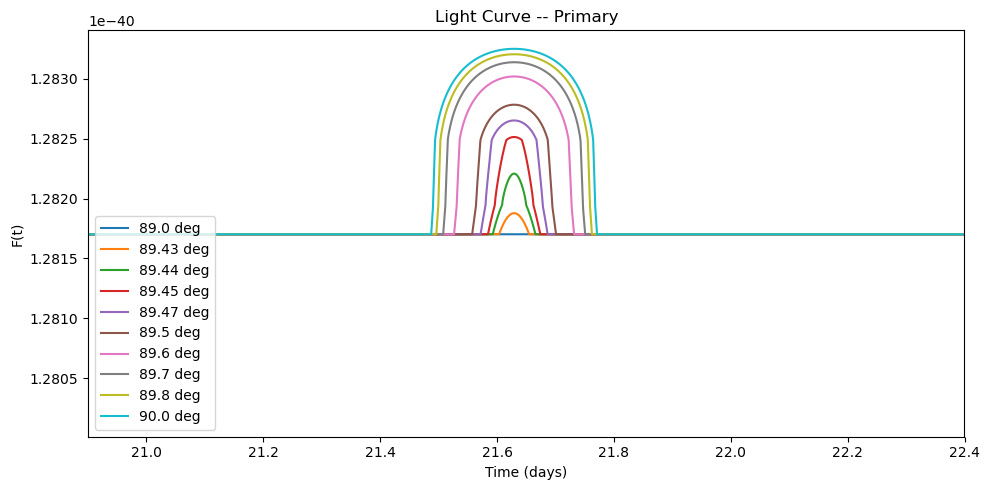

In [4]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(inclinations)):
    ax.plot((binaries_inc[i].t).to(u.day).value, binaries_inc[i].geo_flux, label=f'{inclinations[i]}')
ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Primary")
ax.set_xlim(20.9, 22.4)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

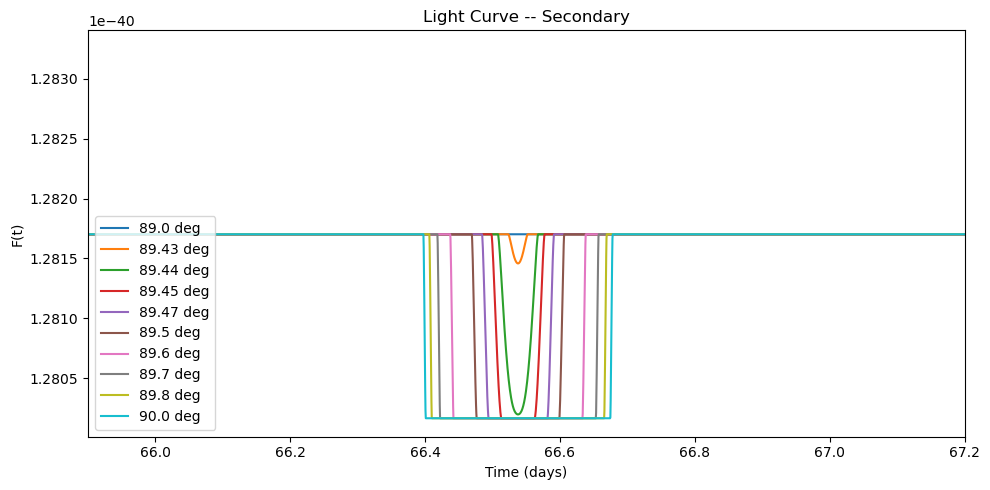

In [5]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(inclinations)):
    ax.plot((binaries_inc[i].t).to(u.day).value, binaries_inc[i].geo_flux, label=f'{inclinations[i]}')

ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Secondary")
ax.set_xlim(65.9, 67.2)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# varying eccentricity

In [ ]:
binaries_ecc = []
eccentricity = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for i in range(len(eccentricity)):

    binary = SLBlensing(
        mass_wd, r_wd, l_wd,
        mass_star, r_star, l_star,
        ecc=eccentricity[i], a=a, d=d, omega=omega_deg, cycles=cycle,
        inc=inc_deg,
        limb_darkening_wd=[0.0, 0.1], limb_darkening_star=[0.44, 0.24],
        N=N
    )
    
    binaries_ecc.append(binary)

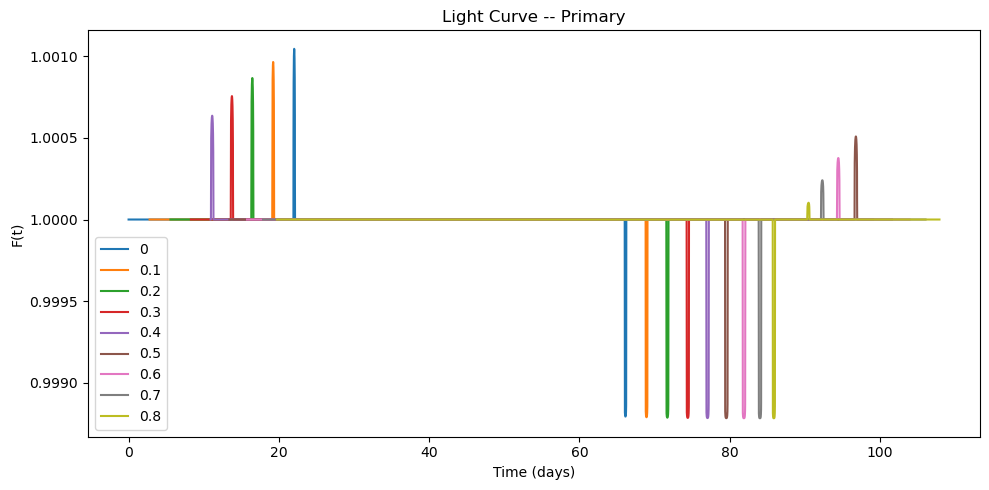

In [7]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(eccentricity)):
    ax.plot((binaries_ecc[i].t).to(u.day).value, binaries_ecc[i].geo_flux / binaries_ecc[i].base_flux , label=f'{eccentricity[i]}')
ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Primary")
# ax.set_xlim(20.9, 25)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

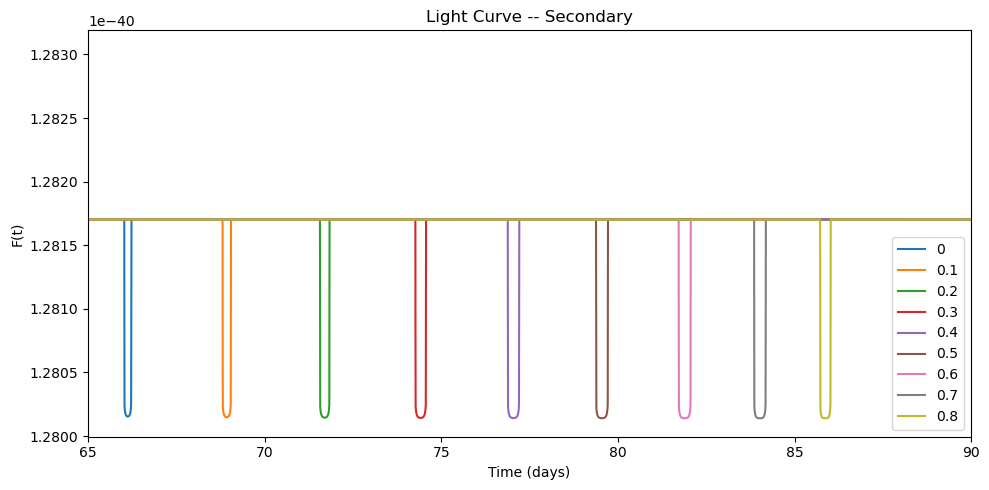

In [8]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(eccentricity)):
    ax.plot((binaries_ecc[i].t).to(u.day).value, binaries_ecc[i].geo_flux, label=f'{eccentricity[i]}')

ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Secondary")
ax.set_xlim(65, 90)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# varying semi-major axis

In [ ]:
binaries_a = []
a_arr = [0.1, 0.2, 0.4, 0.5, 0.6, 0.65, 0.67, 0.7] * u.au

for i in range(len(a_arr)):

    binary = SLBlensing(
        mass_wd, r_wd, l_wd,
        mass_star, r_star, l_star,
        ecc, a=a_arr[i], d=d, omega=omega_deg, cycles=cycle,
        inc=inc_deg,
        limb_darkening_wd=[0.0, 0.1], limb_darkening_star=[0.44, 0.24],
        N=N
    )
    
    binaries_a.append(binary)

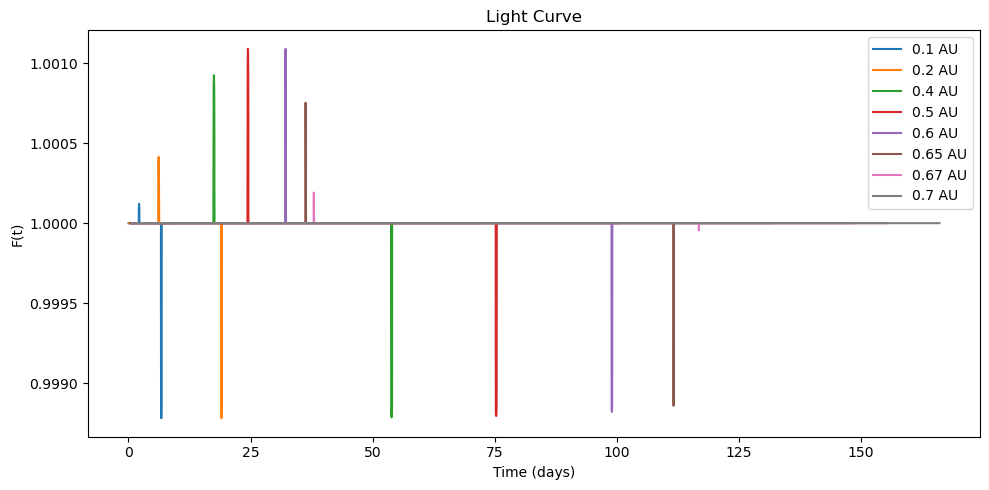

In [10]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(a_arr)):
    ax.plot((binaries_a[i].t).to(u.day).value, binaries_a[i].geo_flux / binaries_a[i].base_flux, label=f'{a_arr[i]}')
ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# varying R_{star}

In [ ]:
binaries_rstars = []
rstars = [0.5, 0.68, 0.7, 0.85, 1.0, 2.0, 5.0] * u.Rsun 

for i in range(len(rstars)):

    binary = SLBlensing(
        mass_wd, r_wd, l_wd,
        mass_star, r_star=rstars[i], l_star=l_star,
        ecc=ecc, a=a, d=d, omega=omega_deg, cycles=cycle,
        inc=inc_deg,
        limb_darkening_wd=[0.0, 0.0], limb_darkening_star=[0.44, 0.24],
        N=N
    )
    
    binaries_rstars.append(binary)

FIGURE OUT WHYYYYYYYYY, SOMETHING SOMETHING ANNULUS????

It's A.

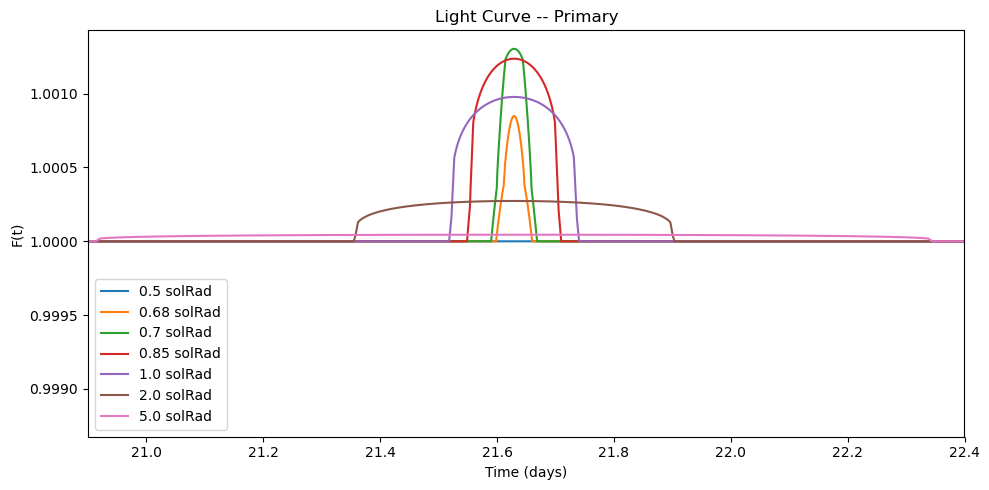

In [12]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(rstars)):
    ax.plot((binaries_rstars[i].t).to(u.day).value, binaries_rstars[i].geo_flux / binaries_rstars[i].base_flux, label=f'{rstars[i]}')
ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Primary")
ax.set_xlim(20.9, 22.4)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

why is it going down?

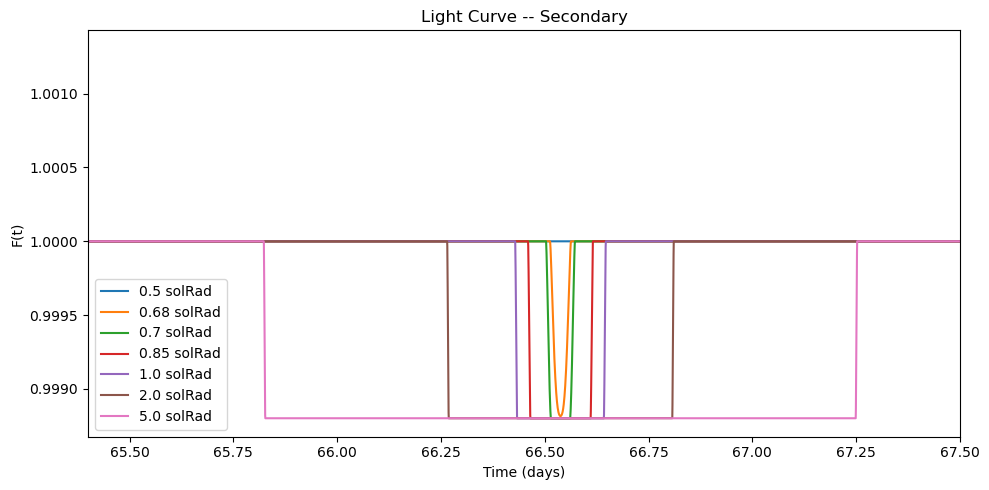

In [13]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(rstars)):
    ax.plot((binaries_rstars[i].t).to(u.day).value, binaries_rstars[i].geo_flux / binaries_rstars[i].base_flux, label=f'{rstars[i]}')
ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Secondary")
ax.set_xlim(65.4, 67.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# varying R_{lens}

In [ ]:
binaries_lens = []
lens = [0.000000001, 0.001, 0.01, 0.02, 0.03] * u.Rsun  

for i in range(len(lens)):

    binary = SLBlensing(
        mass_wd, r_wd=lens[i], l_wd=l_wd,
        mass_star=mass_star, r_star=r_star, l_star=l_star,
        ecc=ecc, a=a, d=d, omega=omega_deg, cycles=cycle,
        inc=inc_deg,
        limb_darkening_wd=[0.0, 0.1], limb_darkening_star=[0.44, 0.24],
        N=N
    )
    
    binaries_lens.append(binary)

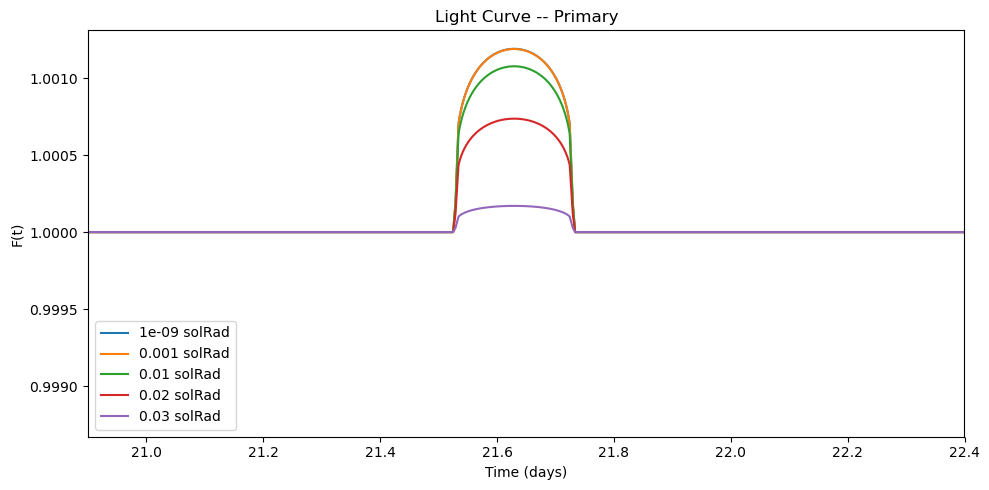

In [15]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(lens)):
    ax.plot((binaries_lens[i].t).to(u.day).value, binaries_lens[i].geo_flux / binaries_lens[i].base_flux, label=f'{lens[i]}')
ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Primary")
ax.set_xlim(20.9, 22.4)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

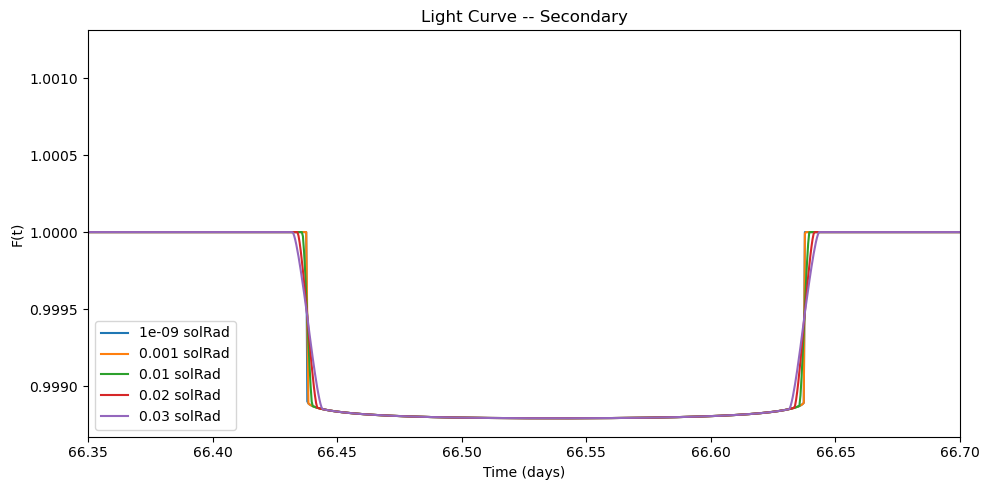

In [16]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(lens)):
    ax.plot((binaries_lens[i].t).to(u.day).value, binaries_lens[i].geo_flux / binaries_lens[i].base_flux, label=f'{lens[i]}')
ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Secondary")
ax.set_xlim(66.35, 66.7)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [17]:
# r_e on mass, see what seperation is necessary